In [ ]:
!pip install pandas numpy matplotlib seaborn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
import zipfile

zip_file = "weblog.csv.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset_folder")

print("Files extracted successfully!")

Files extracted successfully!


In [ ]:
import os

os.listdir("dataset_folder")


df = pd.read_csv("dataset_folder/weblog.csv")

In [ ]:
df.head()

,IP,Time,URL,Staus
0,10.128.2.1,[29/Nov/2017:06:58:55,GET /login.php HTTP/1.1,200
1,10.128.2.1,[29/Nov/2017:06:59:02,POST /process.php HTTP/1.1,302
2,10.128.2.1,[29/Nov/2017:06:59:03,GET /home.php HTTP/1.1,200
3,10.131.2.1,[29/Nov/2017:06:59:04,GET /js/vendor/moment.min.js HTTP/1.1,200
4,10.130.2.1,[29/Nov/2017:06:59:06,GET /bootstrap-3.3.7/js/bootstrap.js HTTP/1.1,200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16007 entries, 0 to 16006
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   IP      16007 non-null  object
 1   Time    16007 non-null  object
 2   URL     16007 non-null  object
 3   Staus   16007 non-null  object
dtypes: object(4)
memory usage: 500.3+ KB


In [ ]:
df.isnull().sum()

,0
IP,0
Time,0
URL,0
Staus,0


In [ ]:
df=df.dropna()

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13437 entries, 0 to 16006
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   IP      13437 non-null  object
 1   Time    13437 non-null  object
 2   URL     13437 non-null  object
 3   Staus   13437 non-null  object
dtypes: object(4)
memory usage: 524.9+ KB


In [ ]:
print(df.columns)

Index(['IP', 'Time', 'URL', 'Staus'], dtype='object')


In [ ]:
top_ips=df['IP'].value_counts().head(10)
print(top_ips)

IP
10.131.0.1    3607
10.128.2.1    3564
10.130.2.1    3447
10.129.2.1    1402
10.131.2.1    1393
sh:              6
[Tue             5
chmod:           2
a.out:           2
rm:              2
Name: count, dtype: int64


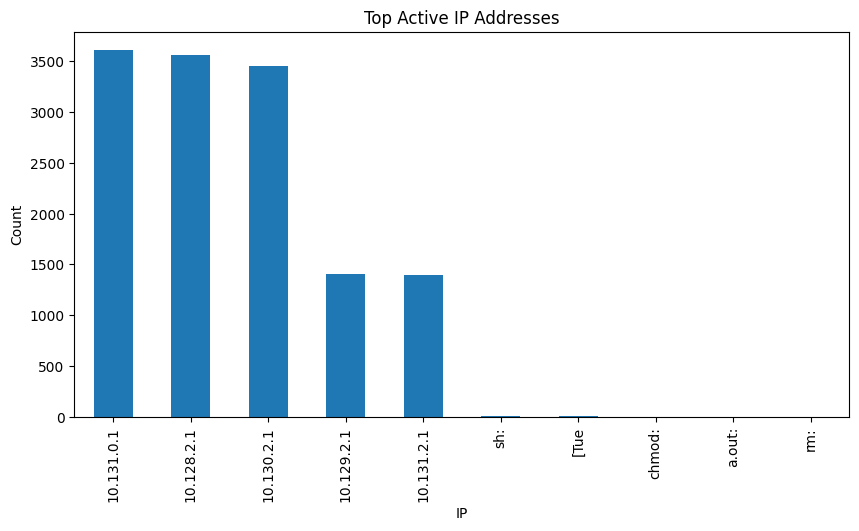

In [ ]:
import matplotlib.pyplot as plt
top_ips.plot(kind='bar', figsize=(10,5))
plt.xlabel('IP')
plt.ylabel('Count')
plt.title('Top Active IP Addresses')
plt.show()

In [ ]:
status_counts=df['Staus'].value_counts()
print(status_counts)

Staus
200             9891
302             2803
304              487
404              188
206               44
2018]              8
No                 4
Aborted            4
2017]              3
Assertion          2
dumped             1
Segmentation       1
found              1
Name: count, dtype: int64


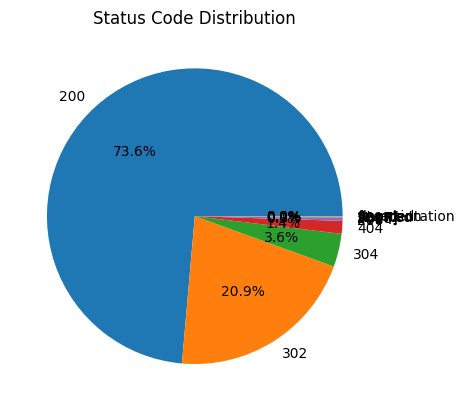

In [ ]:
status_counts.plot(kind='pie', autopct='%1.1f%%',)
plt.title('Status Code Distribution')
plt.ylabel("")
plt.show()

In [ ]:
traffic_counts=df['IP'].value_counts()
suspicious_ips=traffic_counts[traffic_counts>100]
print(suspicious_ips)

IP
10.131.0.1    3607
10.128.2.1    3564
10.130.2.1    3447
10.129.2.1    1402
10.131.2.1    1393
Name: count, dtype: int64


In [ ]:
failed_requests=df[df['Staus'].isin([401,403,404,500])]
print(failed_requests.head())


Empty DataFrame
Columns: [IP, Time, URL, Staus]
Index: []


In [ ]:
failed_ip_counts=failed_requests['IP'].value_counts()
attackers=failed_ip_counts[failed_ip_counts>10]
print(attackers)

Series([], Name: count, dtype: int64)


In [ ]:
suspicious_urls=df[df['URL'].str.contains("admin/login",case=False, na=False)]
print(suspicious_urls.head())

Empty DataFrame
Columns: [IP, Time, URL, Staus]
Index: []


In [ ]:
df['Time'] = df['Time'].str.replace('[', '', regex=False).str.replace(']', '', regex=False)
df['Time'] = pd.to_datetime(df['Time'], format='%d/%b/%Y:%H:%M:%S', errors='coerce')
df['Time'].head()

,Time
0,2017-11-29 06:58:55
1,2017-11-29 06:59:02
2,2017-11-29 06:59:03
3,2017-11-29 06:59:04
4,2017-11-29 06:59:06


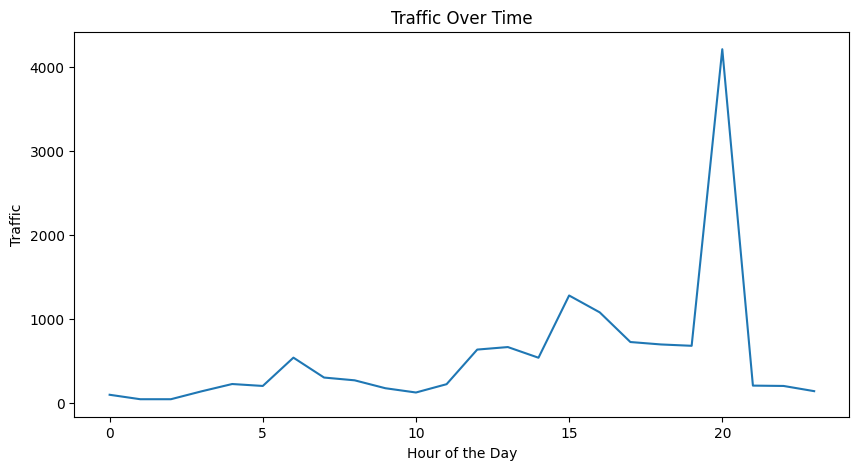

In [ ]:
traffic_time=df.groupby(df['Time'].dt.hour).size()
traffic_time.plot(figsize=(10,5))
plt.xlabel('Hour of the Day')
plt.ylabel('Traffic')
plt.title('Traffic Over Time')
plt.show()

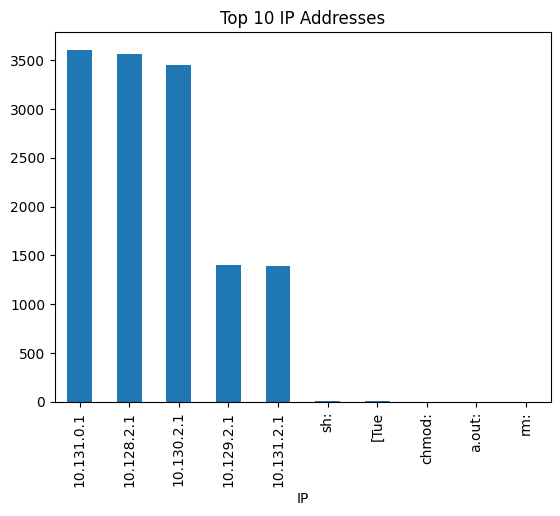

In [ ]:
top_ips.plot(kind='bar')
plt.title('Top 10 IP Addresses')
plt.show()

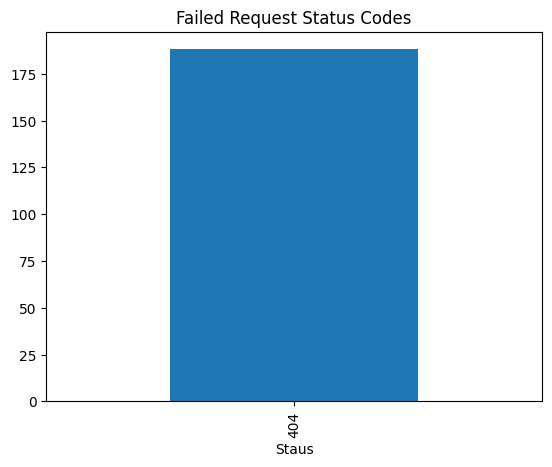

In [ ]:
failed_requests = df[df['Staus'].isin(['401','403','404','500'])]
if not failed_requests.empty:
    failed_requests['Staus'].value_counts().plot(kind='bar')
    plt.title('Failed Request Status Codes')
    plt.show()
else:
    print("No failed requests (401, 403, 404, 500) found to plot.")

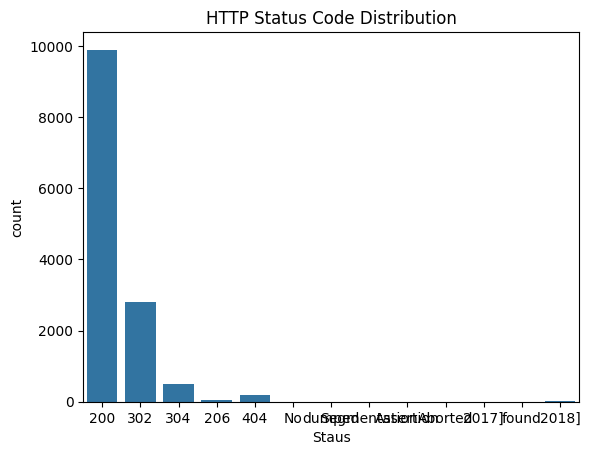

In [ ]:
import seaborn as sns
sns.countplot(x='Staus', data=df)
plt.title('HTTP Status Code Distribution')
plt.show()

In [ ]:
print("SECURITY SUMMARY")
print(f"Total number of requests: {len(df)}")
print(f"Number of unique IP addresses: {df['IP'].nunique()}")
print(f"Number of failed requests: {len(failed_requests)}")
print(f"Number of suspicious URLs: {len(suspicious_urls)}")
print(f"Number of attackers: {len(attackers)}")

SECURITY SUMMARY
Total number of requests: 13437
Number of unique IP addresses: 16
Number of failed requests: 188
Number of suspicious URLs: 0
Number of attackers: 0


IP Address:
An IP address identifies devices communicating over a network.

Ports:
Ports help identify services.

Protocols:
Protocols define communication rules.

Traffic Behavior:
High traffic spikes may indicate:-
Heavy user activity
Bot attacks
DDoS attempts